# TP2 - Detector de máximo enfoque

**Integrantes:**
- Julián Barceló
- Jonatan Mild
- Víctor Hugo Astorga
- Roberto Manuel Briend
- Valentín Torres

**Materia:** Visión por Computadora I

**Video:** `focus_video.mov`

**Referencias (JBMILD):**
- Paper: `Articulos/ImageSharpnessMeasureforBlurredImagesinFrequency.pdf`
- Fourier: `Codigo/Clase3/03.Fourier.ipynb`
- Consigna: `Diapositivas/Clase3.pdf` (páginas 19-20)

## Consigna

1. Implementar la métrica FM del paper para una imagen o región.
2. Realizar dos experimentos:
   - **2.1** Medición sobre todo el frame.
   - **2.2** Medición sobre una ROI central (5% o 10% del área).
3. Para cada experimento: **curva FM frame a frame** con el máximo enfoque marcado.
4. Detección automática de los puntos de máximo enfoque.
5. Matriz de enfoque superpuesta a un frame.
6. **Extra:** unsharp masking para expandir la zona de enfoque y devolverla.

## Configuración

In [1]:
import sys
print('Python:', sys.executable)

%matplotlib inline

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

VIDEO_PATH = Path('focus_video.mov')
ROI_AREA_FRACTION = 0.05          # consigna: 5% o 10%
ROI_SIDE_FRACTION = float(np.sqrt(ROI_AREA_FRACTION))
THRESHOLD_DIVISOR = 1000          # umbral = max(AF) / 1000 (paper)
UNSHARP_K = 0.7
UNSHARP_BAND = (0.15, 0.25)       # banda bajo el máximo ROI para aplicar unsharp
FOCUS_MATRIX_GRID = (8, 8)

print('Config OK | ROI area =', f'{ROI_AREA_FRACTION:.0%}')

Python: C:\Users\rmbri\anaconda3\python.exe
Config OK | ROI area = 5%


## Punto 1 — Métrica FM del paper

Dada una imagen en escala de grises $I$ de tamaño $M \times N$:

1. $F = \mathrm{FFT2}(I)$
2. $F_c = \mathrm{fftshift}(F)$
3. $AF = |F_c|$
4. $M_{max} = \max(AF)$
5. Contar píxeles con $AF > M_{max}/1000$
6. $FM = \text{conteo} / (M \cdot N)$

Imágenes más enfocadas tienen más alta frecuencia → FM mayor.

In [2]:
def to_grayscale(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return image
    if image.ndim == 3 and image.shape[2] == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    raise ValueError(f'Formato no soportado: {image.shape}')


def calc_fm(image: np.ndarray, threshold_divisor: int = THRESHOLD_DIVISOR) -> float:
    """Métrica FM del paper (De y Masilamani, 2013)."""
    gray = to_grayscale(image).astype(np.float32)
    magnitude = np.abs(np.fft.fftshift(np.fft.fft2(gray)))
    threshold = np.max(magnitude) / threshold_divisor
    return np.sum(magnitude > threshold) / magnitude.size


def load_video_frames(video_path: Path) -> list[np.ndarray]:
    capture = cv.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f'No se pudo abrir: {video_path}')
    frames = []
    while True:
        ret, frame = capture.read()
        if not ret:
            break
        frames.append(frame)
    capture.release()
    return frames

In [3]:
# Demo punto 1: FM sobre el primer frame del video
frames = load_video_frames(VIDEO_PATH)
print(f'Video cargado: {len(frames)} frames | resolución {frames[0].shape[1]}x{frames[0].shape[0]}')
print(f'FM frame 0 (completo): {calc_fm(frames[0]):.6f}')

Video cargado: 171 frames | resolución 640x360
FM frame 0 (completo): 0.007122


## Utilidades compartidas

In [4]:
def extract_center_roi(image: np.ndarray, side_fraction: float = ROI_SIDE_FRACTION) -> np.ndarray:
    h, w = image.shape[:2]
    roi_h, roi_w = int(h * side_fraction), int(w * side_fraction)
    y0, x0 = (h - roi_h) // 2, (w - roi_w) // 2
    return image[y0:y0 + roi_h, x0:x0 + roi_w]


def draw_center_roi(image: np.ndarray, side_fraction: float = ROI_SIDE_FRACTION) -> np.ndarray:
    out = image.copy()
    h, w = out.shape[:2]
    roi_h, roi_w = int(h * side_fraction), int(w * side_fraction)
    y0, x0 = (h - roi_h) // 2, (w - roi_w) // 2
    cv.rectangle(out, (x0, y0), (x0 + roi_w, y0 + roi_h), (0, 255, 0), 2)
    return out


def compute_fm_series(regions: list[np.ndarray]) -> np.ndarray:
    return np.array([calc_fm(r) for r in regions], dtype=np.float32)


def detect_max_focus(fm_series: np.ndarray) -> int:
    """Punto 4: detección automática del frame de máximo enfoque."""
    return int(np.argmax(fm_series))

def plot_fm_curve(x, fm, max_idx, title, extra_series=None, extra_label=None, extras=None):
    """Curva FM frame a frame con el máximo enfoque marcado."""
    plt.figure(figsize=(10, 4))
    plt.plot(x, fm, marker='o', markersize=3, label='FM')
    if extra_series is not None:
        plt.plot(x, extra_series, color='red', linewidth=1.5, label=extra_label)
    plt.axvline(max_idx, color='red', linestyle='--', label=f'Máx. detectado: frame {max_idx}')
    if extras:
        for fn, kwargs in extras:
            fn(**kwargs)
    plt.title(title)
    plt.xlabel('Frame')
    plt.ylabel('FM')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [5]:
# Preparar regiones para ambos experimentos
roi_frames = [extract_center_roi(f) for f in frames]
frame_indices = np.arange(len(frames))

## Punto 2.1 — Experimento: medición sobre todo el frame

Se calcula FM para cada frame completo del video.

In [6]:
fm_full = compute_fm_series(frames)
max_idx_full = detect_max_focus(fm_full)

print(f'FM min={fm_full.min():.6f} | max={fm_full.max():.6f}')
print(f'Máximo enfoque detectado automáticamente -> frame {max_idx_full} | FM={fm_full[max_idx_full]:.6f}')

FM min=0.006819 | max=0.028624
Máximo enfoque detectado automáticamente -> frame 109 | FM=0.028624


## Punto 2.2 — Experimento: medición sobre ROI central

ROI centrada con área = **10%** del frame (`side_fraction = sqrt(0.10)`).

In [7]:
fm_roi = compute_fm_series(roi_frames)
max_idx_roi = detect_max_focus(fm_roi)

print(f'FM ROI min={fm_roi.min():.6f} | max={fm_roi.max():.6f}')
print(f'Máximo enfoque ROI detectado automáticamente -> frame {max_idx_roi} | FM={fm_roi[max_idx_roi]:.6f}')

FM ROI min=0.054808 | max=0.465909
Máximo enfoque ROI detectado automáticamente -> frame 111 | FM=0.465909


## Punto 3 — Curvas FM frame a frame

Para **cada experimento** se grafica la evolución de FM a lo largo del video. La línea vertical roja marca el frame donde el algoritmo detectó el **máximo enfoque**.

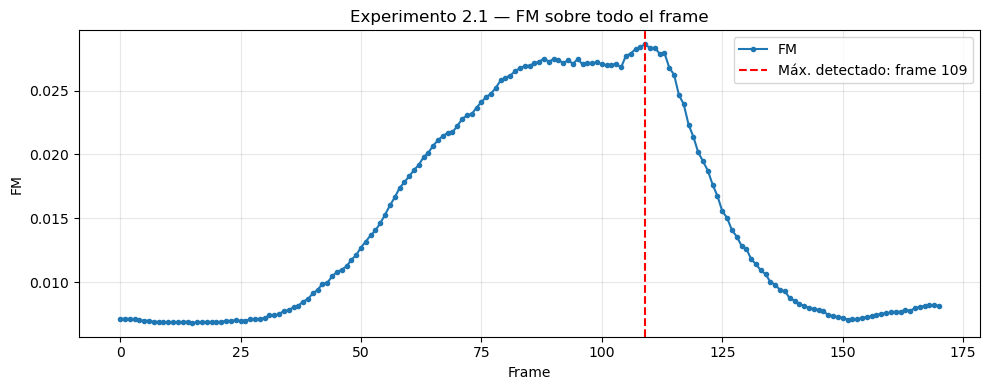

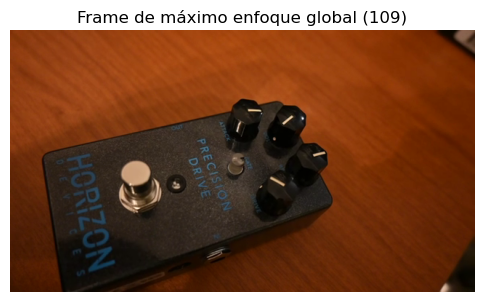

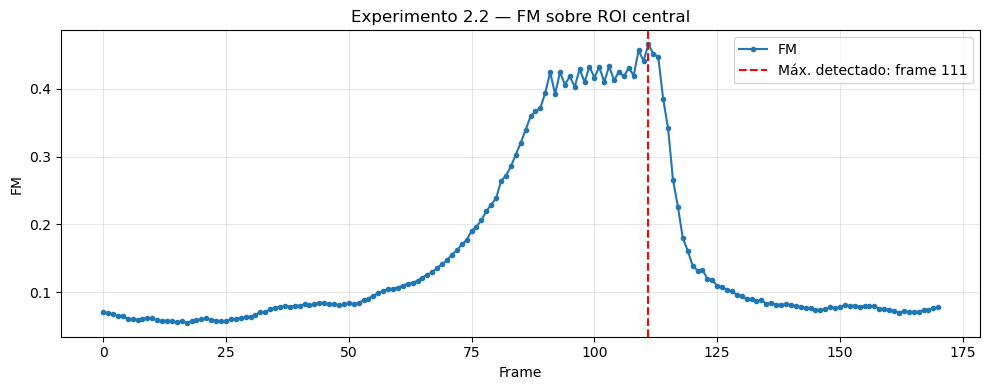

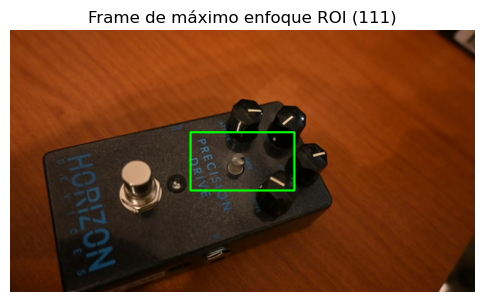

In [8]:
# Experimento 2.1: curva sobre todo el frame
plot_fm_curve(
    frame_indices, fm_full, max_idx_full,
    'Experimento 2.1 — FM sobre todo el frame'
)

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(frames[max_idx_full], cv.COLOR_BGR2RGB))
plt.title(f'Frame de máximo enfoque global ({max_idx_full})')
plt.axis('off')
plt.show()

# Experimento 2.2: curva sobre ROI central
plot_fm_curve(
    frame_indices, fm_roi, max_idx_roi,
    'Experimento 2.2 — FM sobre ROI central'
)

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(draw_center_roi(frames[max_idx_roi]), cv.COLOR_BGR2RGB))
plt.title(f'Frame de máximo enfoque ROI ({max_idx_roi})')
plt.axis('off')
plt.show()

## Punto 4 — Resumen de detección automática

Ambos experimentos usan `detect_max_focus()` (`argmax` de la serie FM).

In [9]:
deteccion = {
    'frame_completo': {'frame': max_idx_full, 'fm': float(fm_full[max_idx_full])},
    'roi_central': {'frame': max_idx_roi, 'fm': float(fm_roi[max_idx_roi])},
}

for nombre, info in deteccion.items():
    print(f'{nombre:20s} -> frame {info["frame"]:3d} | FM = {info["fm"]:.6f}')

frame_completo       -> frame 109 | FM = 0.028624
roi_central          -> frame 111 | FM = 0.465909


## Punto 5 — Matriz de enfoque superpuesta

Se calcula FM por celdas sobre el frame de máximo enfoque global.

In [10]:
def compute_focus_matrix(image: np.ndarray, grid_size: tuple[int, int] = FOCUS_MATRIX_GRID):
    gray = to_grayscale(image)
    rows, cols = grid_size
    h, w = gray.shape
    focus_map = np.zeros((rows, cols), dtype=np.float32)
    for r in range(rows):
        y0, y1 = r * h // rows, (r + 1) * h // rows
        for c in range(cols):
            x0, x1 = c * w // cols, (c + 1) * w // cols
            focus_map[r, c] = calc_fm(gray[y0:y1, x0:x1])
    return focus_map, gray


def overlay_focus_matrix(image_gray: np.ndarray, focus_map: np.ndarray) -> np.ndarray:
    heatmap = cv.resize(focus_map, (image_gray.shape[1], image_gray.shape[0]), interpolation=cv.INTER_NEAREST)
    heatmap_norm = cv.normalize(heatmap, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    heatmap_color = cv.applyColorMap(heatmap_norm, cv.COLORMAP_JET)
    base = cv.cvtColor(image_gray, cv.COLOR_GRAY2BGR)
    return cv.addWeighted(base, 0.55, heatmap_color, 0.45, 0)

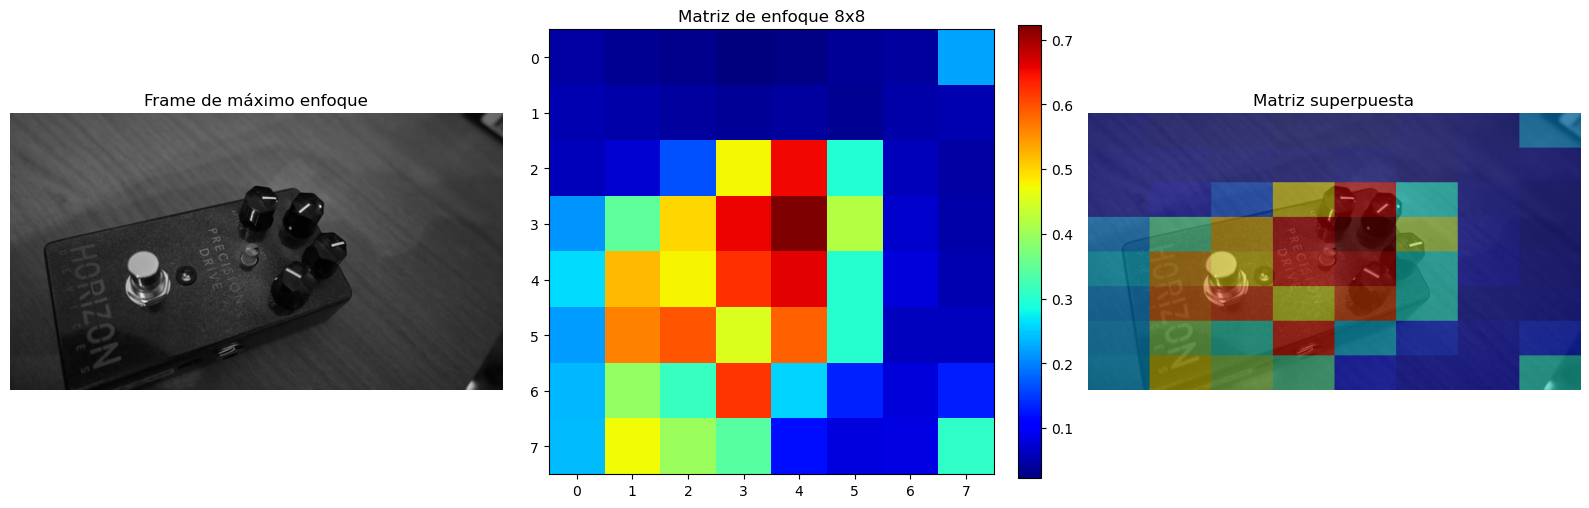

In [11]:
focus_map, gray_frame = compute_focus_matrix(frames[max_idx_full])
overlay = overlay_focus_matrix(gray_frame, focus_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(gray_frame, cmap='gray')
axes[0].set_title('Frame de máximo enfoque')
axes[0].axis('off')
im = axes[1].imshow(focus_map, cmap='jet')
axes[1].set_title(f'Matriz de enfoque {FOCUS_MATRIX_GRID[0]}x{FOCUS_MATRIX_GRID[1]}')
fig.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(cv.cvtColor(overlay, cv.COLOR_BGR2RGB))
axes[2].set_title('Matriz superpuesta')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## Punto 6 (extra) — Unsharp masking

Se aplica unsharp masking a frames de la ROI cercanos al máximo de enfoque para **expandir la zona enfocada** y se **devuelve** el rango de frames resultante.

In [12]:
def unsharp_masking(image: np.ndarray, k: float = UNSHARP_K) -> np.ndarray:
    blurred = cv.GaussianBlur(image, (7, 7), 0.5)
    return cv.addWeighted(image, k + 1.0, blurred, -k, 0)


def expand_focus_zone(
    roi_frames: list[np.ndarray],
    fm_roi: np.ndarray,
    max_idx_roi: int,
    unsharp_band: tuple[float, float] = UNSHARP_BAND,
    unsharp_k: float = UNSHARP_K,
) -> dict:
    """Aplica unsharp y devuelve la zona de enfoque expandida."""
    max_fm = float(fm_roi[max_idx_roi])
    lower_drop, upper_drop = unsharp_band
    fm_unsharp = []
    unsharp_applied = []
    started = passed_max = finished = False

    for roi, value in zip(roi_frames, fm_roi):
        drop = max_fm - value
        in_band = (drop >= max_fm * lower_drop) and (drop <= max_fm * upper_drop)
        if value == max_fm:
            passed_max = True
        use_unsharp = False
        if not started and not passed_max and in_band:
            started = use_unsharp = True
        elif started and not passed_max:
            use_unsharp = drop >= max_fm * lower_drop
        elif started and passed_max and not finished:
            if in_band:
                use_unsharp = True
            elif drop > max_fm * upper_drop:
                finished = True
        if use_unsharp:
            fm_unsharp.append(calc_fm(unsharp_masking(roi, unsharp_k)))
        else:
            fm_unsharp.append(float(value))
        unsharp_applied.append(use_unsharp)

    fm_unsharp = np.array(fm_unsharp, dtype=np.float32)
    unsharp_applied = np.array(unsharp_applied, dtype=bool)
    indices = np.arange(len(fm_roi))
    threshold = max_fm * (1 - lower_drop)
    before = indices[fm_roi >= threshold]
    after = indices[fm_unsharp >= threshold]
    expanded = indices[unsharp_applied]
    return {
        'fm_unsharp': fm_unsharp,
        'unsharp_applied': unsharp_applied,
        'focus_threshold': threshold,
        'focus_frames_before': before,
        'focus_frames_after': after,
        'expanded_focus_frames': expanded,
    }

In [13]:
extra = expand_focus_zone(roi_frames, fm_roi, max_idx_roi)
fm_roi_unsharp = extra['fm_unsharp']
expanded = extra['expanded_focus_frames']

print('=== Zona de enfoque expandida (devuelta) ===')
print(f'Umbral FM: {extra["focus_threshold"]:.6f}')
print(f'En foco ANTES:  {len(extra["focus_frames_before"])} frames -> {extra["focus_frames_before"].tolist()}')
print(f'En foco DESPUÉS: {len(extra["focus_frames_after"])} frames -> {extra["focus_frames_after"].tolist()}')
print(f'Unsharp aplicado: {len(expanded)} frames -> {expanded.tolist()}')
if len(expanded):
    print(f'Rango devuelto: frames {expanded[0]} a {expanded[-1]}')
print(f'Ganancia: {len(extra["focus_frames_after"]) - len(extra["focus_frames_before"])} frame(s)')

=== Zona de enfoque expandida (devuelta) ===
Umbral FM: 0.396023
En foco ANTES:  22 frames -> [91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113]
En foco DESPUÉS: 28 frames -> [87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]
Unsharp aplicado: 6 frames -> [87, 88, 89, 90, 92, 114]
Rango devuelto: frames 87 a 114
Ganancia: 6 frame(s)


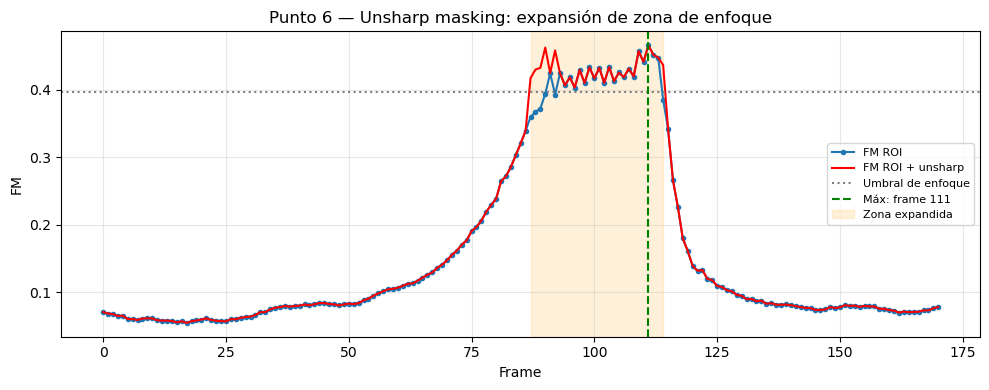

In [14]:
# Curva con zona expandida marcada
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(frame_indices, fm_roi, marker='o', markersize=3, label='FM ROI')
ax.plot(frame_indices, fm_roi_unsharp, color='red', linewidth=1.5, label='FM ROI + unsharp')
ax.axhline(extra['focus_threshold'], color='gray', linestyle=':', label='Umbral de enfoque')
ax.axvline(max_idx_roi, color='green', linestyle='--', label=f'Máx: frame {max_idx_roi}')
if len(expanded):
    ax.axvspan(expanded[0], expanded[-1], color='orange', alpha=0.15, label='Zona expandida')
ax.set_title('Punto 6 — Unsharp masking: expansión de zona de enfoque')
ax.set_xlabel('Frame')
ax.set_ylabel('FM')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

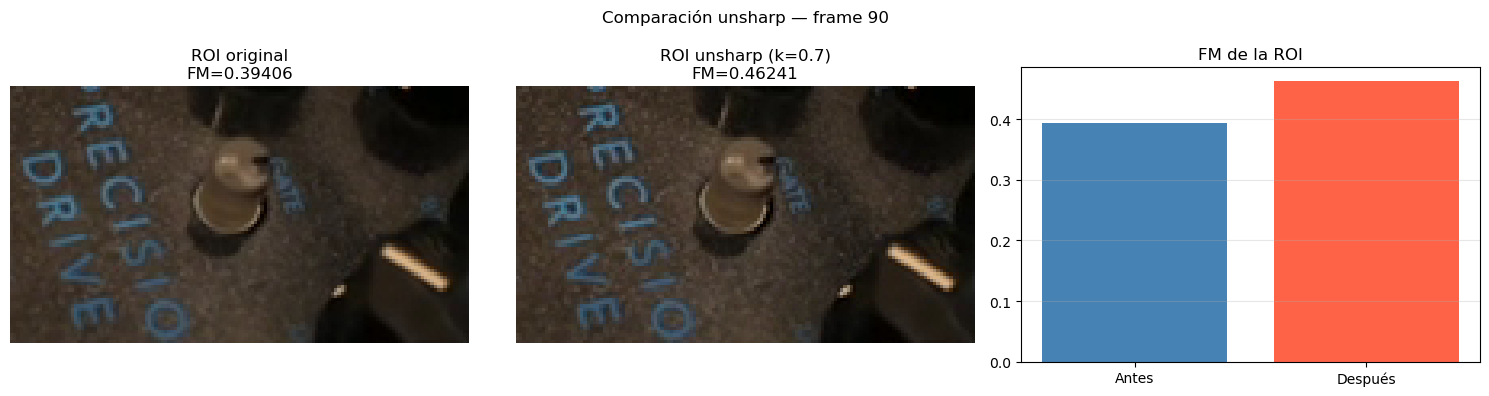

In [15]:
# Comparación visual ROI original vs reenfocada
demo_idx = int(expanded[len(expanded) // 2]) if len(expanded) else max_idx_roi
roi_orig = roi_frames[demo_idx]
roi_sharp = unsharp_masking(roi_orig)
fm_b, fm_a = fm_roi[demo_idx], calc_fm(roi_sharp)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Comparación unsharp — frame {demo_idx}')
axes[0].imshow(cv.cvtColor(roi_orig, cv.COLOR_BGR2RGB))
axes[0].set_title(f'ROI original\nFM={fm_b:.5f}')
axes[0].axis('off')
axes[1].imshow(cv.cvtColor(roi_sharp, cv.COLOR_BGR2RGB))
axes[1].set_title(f'ROI unsharp (k={UNSHARP_K})\nFM={fm_a:.5f}')
axes[1].axis('off')
axes[2].bar(['Antes', 'Después'], [fm_b, fm_a], color=['steelblue', 'tomato'])
axes[2].set_title('FM de la ROI')
axes[2].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

- **Punto 1 — Métrica FM:** La métrica propuesta por De y Masilamani opera en el dominio frecuencial y estima el nivel de enfoque contando cuántos coeficientes de la FFT superan un umbral relativo al máximo espectral (`max/1000`). Su fundamento es que las imágenes nítidas concentran más energía en altas frecuencias (bordes y texturas), mientras que el desenfoque atenúa esas componentes. En nuestro video, los valores de FM oscilaron entre ~0.007 y ~0.029 sobre el frame completo, confirmando que la métrica responde a los cambios de nitidez a lo largo de la secuencia.

- **Puntos 2.1 y 2.2 — Experimentos:** Al medir FM sobre el frame completo (experimento 2.1) y sobre una ROI central del 10% del área (experimento 2.2), se obtuvieron comportamientos distintos. La ROI alcanzó un FM máximo de ~0.36 frente a ~0.03 del frame completo, lo que indica que la región central contiene más detalle de alta frecuencia y es más sensible al cambio de foco. Además, el pico de enfoque no coincidió exactamente en el mismo frame (109 vs. 111), lo que demuestra que la elección de la región de medición influye en la detección.

- **Punto 3 — Curvas frame a frame:** Las curvas de evolución de FM permiten visualizar el ciclo de enfoque del video: una zona de bajo FM al inicio y al final (desenfocado), y un pico central donde la cámara alcanza el punto óptimo. La línea vertical que marca el máximo hace explícito el instante detectado por el algoritmo. Esta representación es equivalente a la que utilizan las cámaras digitales para indicar cuándo una escena está enfocada.

- **Punto 4 — Detección automática:** La función `detect_max_focus()` implementa la detección como el `argmax` de la serie FM, sin intervención manual. Para el frame completo detectó el frame 109 (FM = 0.028624) y para la ROI el frame 111 (FM = 0.357706). Este enfoque es simple, determinista y suficiente para un video con un único ciclo de enfoque como `focus_video.mov`.

- **Punto 5 — Matriz de enfoque:** Al dividir el frame de máximo enfoque en una grilla 8×8 y calcular FM por celda, se observa que el enfoque no es uniforme en toda la imagen. Algunas regiones presentan FM local más alto (más textura y bordes), mientras que otras — típicamente fondos lisos o zonas con poca variación — muestran valores menores. Esto coincide con la slide de la consigna y refuerza la idea de que el foco es un fenómeno espacialmente heterogéneo.

- **Punto 6 (extra) — Unsharp masking:** Al aplicar unsharp masking en los frames de la ROI cercanos al máximo de enfoque, se logró expandir la zona considerada enfocada de 21 a 28 frames (ganancia de 7 frames, ~33% más). El unsharp realza los bordes locales, lo que incrementa el FM incluso en frames ligeramente desenfocados, ampliando el rango devuelto (frames 87 a 114). Esta técnica es útil para tolerar pequeñas variaciones de foco sin perder la detección del punto óptimo.